# Fitting spectra, including Raman Scattering corrections 

## This notebook demonstrates how to fit an input spectrum, allowing for Raman affects 

## v1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from ocpy.utils import plotting
from ocpy.hydrolight import loisel23

from bing.rt import raman
from bing.rt import rrs
from bing import rt as bing_rt
from bing.fitting import l23 as fit_l23
from bing.parameters import standard
from bing import plotting as bing_plot
from bing import evaluate as bing_eval

%matplotlib inline

# Fit first without Raman

In [5]:
idx = 170
p = standard.expb_pow(satellite='PACE', add_noise=True, variable_Gordon=False)#,
                     #nsteps=1000, nburn=100)  
chains, models, prep_dict, idx, extras = fit_l23.fit_one(p, idx)

idx=170
Running burn-in


100%|█████████████████████████████████████| 1000/1000 [00:01<00:00, 576.88it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [01:23<00:00, 478.75it/s]


## Show fit

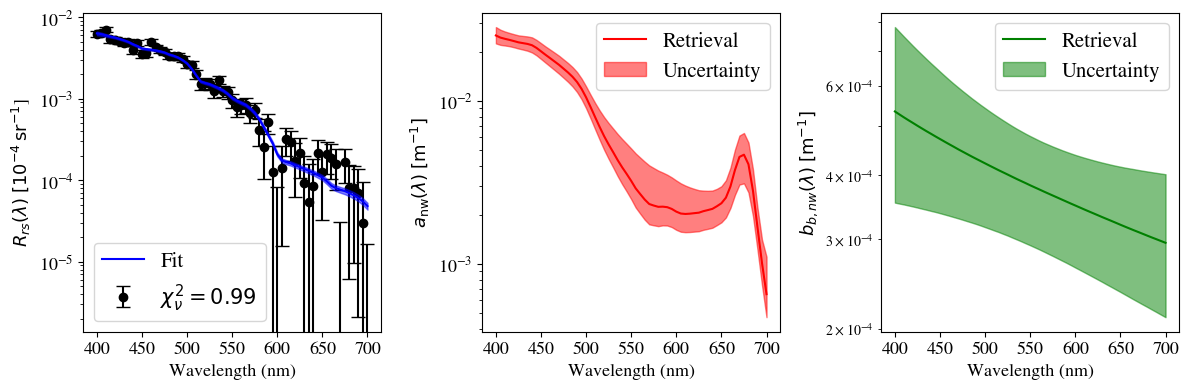

In [6]:
_ = bing_plot.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                show=True,
                Rrs_true=dict(wave=models[0].wave, spec=prep_dict['model_Rrs'], var=prep_dict['model_varRrs']),
                log_abb=True )

## Stats

In [7]:
stats = bing_eval.calc_stats(chains, names=models[0].pnames+models[1].pnames)
stats

{'names': ['Adg', 'Sdg', 'Aph', 'Bnw', 'beta'],
 'med': array([-1.7416102 ,  0.01558912, -1.915461  , -3.4574142 ,  1.085985  ],
       dtype=float32),
 'p14': array([-1.8164222 ,  0.01193261, -2.0512137 , -3.534003  ,  0.33896482],
       dtype=float32),
 'p86': array([-1.6699395 ,  0.01875595, -1.8258498 , -3.3903573 ,  1.7502803 ],
       dtype=float32)}

## Show IOPs at excitation wavelengths

In [8]:
a_ex = models[0].eval_a_ex(stats['med'][:3])
a = models[0].eval_a(stats['med'][:3])
# non-water
#turn_off = np.array([0., 0., -3])
turn_off = np.array([0., 0., 0])
anw_ex = models[0].eval_anw(stats['med'][:3]+turn_off, wave=models[0].wave_ex)
anw = models[0].eval_anw(stats['med'][:3]+turn_off)

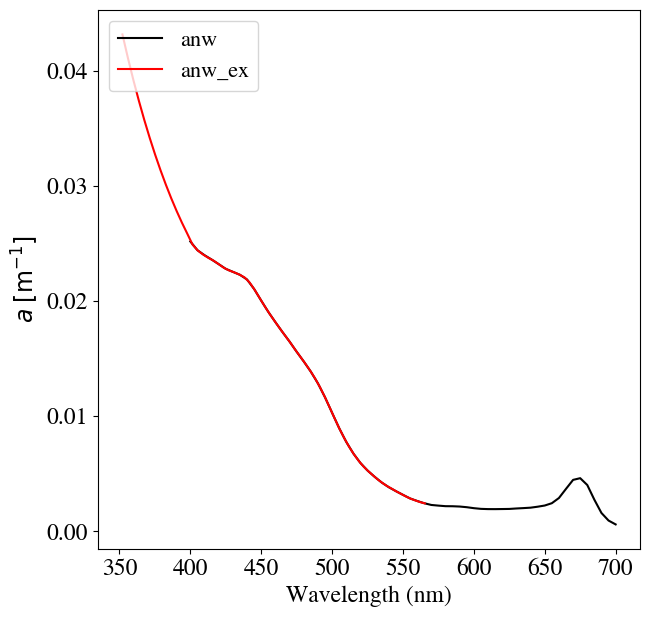

In [9]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
#ax.plot(models[0].wave, a.flatten(), label='a', color='black')
#ax.plot(models[0].wave_ex, a_ex.flatten(), label='a_ex', color='red')
ax.plot(models[0].wave, anw.flatten(), label='anw', color='black')
ax.plot(models[0].wave_ex, anw_ex.flatten(), label='anw_ex', color='red')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$a \; \rm [m^{-1}]$')
#ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='upper left', fontsize=16.)
plt.show()

## Load 

In [3]:
l23_10 = loisel23.load_ds(1,0)
l23_20 = loisel23.load_ds(2,0)
l23_40 = loisel23.load_ds(4,0)
#
wave = l23_10.Lambda.data

In [4]:
wave

array([350., 355., 360., 365., 370., 375., 380., 385., 390., 395., 400.,
       405., 410., 415., 420., 425., 430., 435., 440., 445., 450., 455.,
       460., 465., 470., 475., 480., 485., 490., 495., 500., 505., 510.,
       515., 520., 525., 530., 535., 540., 545., 550., 555., 560., 565.,
       570., 575., 580., 585., 590., 595., 600., 605., 610., 615., 620.,
       625., 630., 635., 640., 645., 650., 655., 660., 665., 670., 675.,
       680., 685., 690., 695., 700., 705., 710., 715., 720., 725., 730.,
       735., 740., 745., 750.], dtype=float32)

In [5]:
i400 = np.argmin(np.abs(wave-400.))

## Analysis wavelengths

In [6]:
gd_iwv = (wave >= 400.) & (wave <= 700.)
# Analysis wavelengths
awave = wave[gd_iwv]

## Excitation wavelengths

In [7]:
wave_ex = raman.emission_to_excitation_wavelength(awave)
wave_ex

array([352.11267, 355.98138, 359.8385 , 363.68417, 367.51837, 371.3412 ,
       375.15268, 378.95288, 382.74182, 386.5196 , 390.2862 , 394.04175,
       397.78622, 401.5197 , 405.24228, 408.95395, 412.65472, 416.34476,
       420.024  , 423.69257, 427.35043, 430.99768, 434.6344 , 438.26056,
       441.87628, 445.48154, 449.07645, 452.66098, 456.23523, 459.79922,
       463.353  , 466.8966 , 470.4301 , 473.95352, 477.46692, 480.9703 ,
       484.46375, 487.94727, 491.42096, 494.8848 , 498.3389 , 501.7832 ,
       505.2178 , 508.64276, 512.05817, 515.4639 , 518.86017, 522.2469 ,
       525.6242 , 528.99207, 532.3505 , 535.69965, 539.0395 , 542.3701 ,
       545.69147, 549.00366, 552.3067 , 555.60065, 558.88544, 562.1613 ,
       565.4281 ], dtype=float32)

# Parse

In [8]:
idx = 170

In [9]:
a = l23_10.a[idx].data
bb = l23_10.bb[idx].data

In [24]:
hydro_Rrs_E = l23_10.Rrs[idx].data
hydro_Rrs_R = l23_40.Rrs[idx].data

# Interpolation

In [10]:
f_a = interp1d(wave, a)
f_bb = interp1d(wave, bb)

In [11]:
# Test
f_a(400.), a[i400]

(array(0.030973), np.float32(0.030973))

# Raman time

## Gordon

In [12]:
Rrs_G = rrs.calc_Rrs(a[gd_iwv], bb[gd_iwv])

## Correction

In [13]:
a_ex = f_a(wave_ex)
bb_ex = f_bb(wave_ex)

In [14]:
bb_R = raman.raman_backscattering_coeff(awave)

Rrs_R_E = rrs.calc_raman_correction_factor(a[gd_iwv], bb[gd_iwv], a_ex, bb_ex, bb_R)

# Plot me

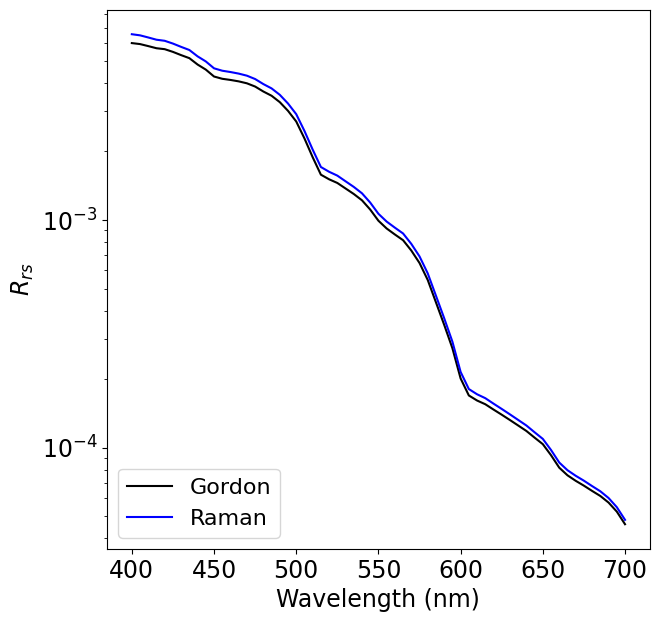

In [16]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
#ax.plot(wave, Rrs_10, label='Inelastic', color='gray')
#ax.plot(wave, Rrs_20, label='Raman', color='blue')
#ax.plot(wave, Rrs_40-Rrs_20, label='Chl', color='green')
ax.plot(awave, Rrs_G, label='Gordon', color='black')
ax.plot(awave, Rrs_G*Rrs_R_E, label='Raman', color='blue')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()

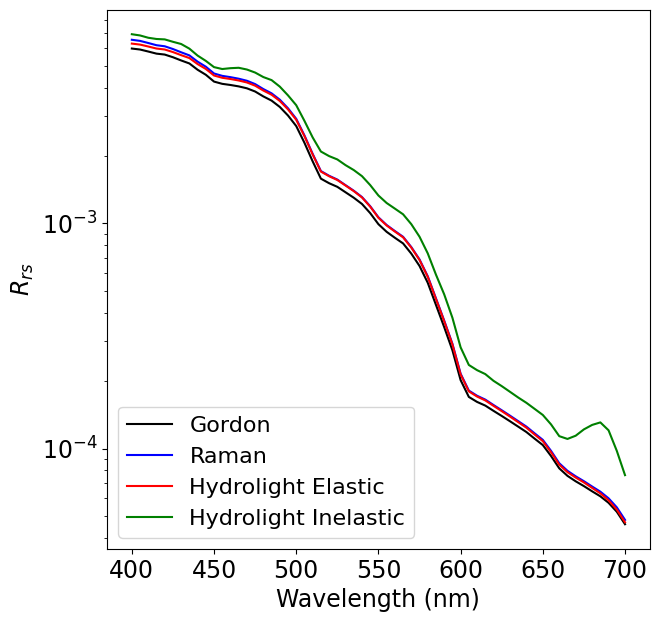

In [27]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
#ax.plot(wave, Rrs_10, label='Inelastic', color='gray')
#ax.plot(wave, Rrs_20, label='Raman', color='blue')
#ax.plot(wave, Rrs_40-Rrs_20, label='Chl', color='green')
ax.plot(awave, Rrs_G, label='Gordon', color='black')
ax.plot(awave, Rrs_G*Rrs_R_E, label='Raman', color='blue')
# Hydrolight
ax.plot(awave, hydro_Rrs_E[gd_iwv], label='Hydrolight Elastic', color='red')
ax.plot(awave, hydro_Rrs_R[gd_iwv], label='Hydrolight Inelastic', color='green')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()

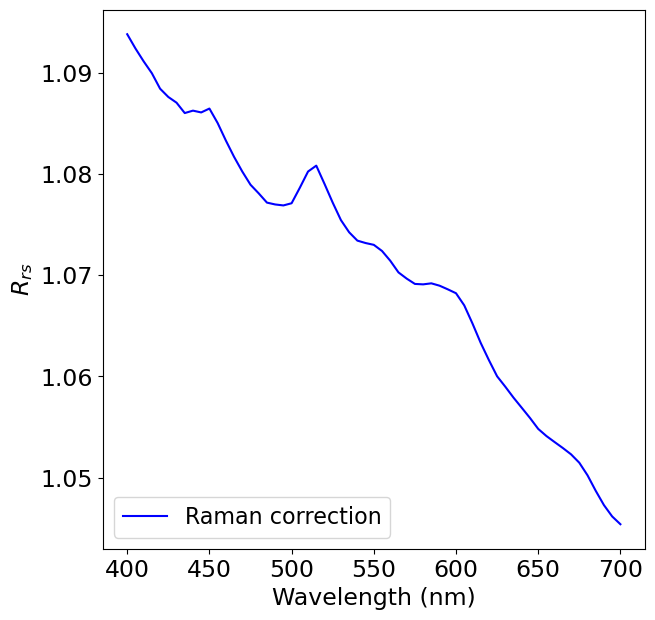

In [41]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
#ax.plot(wave, Rrs_10, label='Inelastic', color='gray')
#ax.plot(wave, Rrs_20, label='Raman', color='blue')
#ax.plot(wave, Rrs_40-Rrs_20, label='Chl', color='green')
ax.plot(awave, Rrs_R_E, label='Raman correction', color='blue')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
#ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()